# Subject 6: Around Simpson's Paradox

**Author:** Youssef Osman  

## Introduction
In this notebook, we analyze the relationship between smoking habits and 20-year survival rates using data from a survey conducted in Whickham, England. The goal is to perform a replicable data analysis to investigate an apparent paradox in mortality rates.

The dataset contains the following columns:
* `Smoker`: Smoking status (Yes/No)
* `Status`: Survival status after 20 years (Alive/Dead)
* `Age`: Age at the time of the first survey

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

## 1. Data Loading and Inspection
We load the data from the CSV file `Subject6_smoking.csv`. We will then inspect the structure of the data and check for any missing values to ensure data integrity.

In [ ]:
df = pd.read_csv('Subject6_smoking.csv')

display(df.head())

print(df.info())

print("\nMissing values:\n", df.isnull().sum())

,Smoker,Status,Age
0,Yes,Alive,21.0
1,Yes,Alive,19.3
2,No,Dead,57.5
3,No,Alive,47.1
4,Yes,Alive,81.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Smoker  1314 non-null   object 
 1   Status  1314 non-null   object 
 2   Age     1314 non-null   float64
dtypes: float64(1), object(2)
memory usage: 30.9+ KB
None

Missing values:
 Smoker    0
Status    0
Age       0
dtype: int64


## 2. Global Mortality Analysis (Question 1)

**Objective:** Tabulate the total number of women alive and dead according to their smoking habits and calculate the mortality rate for each group.

We calculate the mortality rate as:
$$\text{Mortality Rate} = \frac{\text{Number of Dead}}{\text{Total in Group}}$$

Status,Alive,Dead,Total,Mortality_Rate
Smoker,,,,
No,502,230,732,0.314208
Yes,443,139,582,0.238832


C:\Users\Youssef Shawky\AppData\Local\Temp\ipykernel_30992\2060815548.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tab1.index, y=tab1['Mortality_Rate'], palette="viridis")


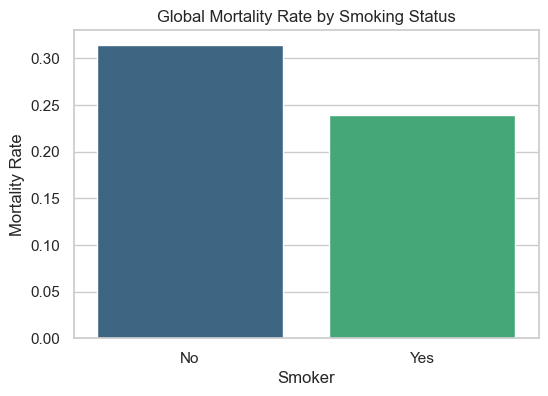

In [ ]:
tab1 = pd.crosstab(df['Smoker'], df['Status'])

tab1['Total'] = tab1['Alive'] + tab1['Dead']
tab1['Mortality_Rate'] = tab1['Dead'] / tab1['Total']

display(tab1)

plt.figure(figsize=(6, 4))
sns.barplot(x=tab1.index, y=tab1['Mortality_Rate'], palette="viridis")
plt.title('Global Mortality Rate by Smoking Status')
plt.ylabel('Mortality Rate')
plt.show()

### Observation
Surprisingly, the data shows that **non-smokers have a higher mortality rate (31.4%)** compared to smokers (23.9%). This counter-intuitive result contradicts medical consensus. This phenomenon suggests the presence of a confounding variable masking the true relationship.

## 3. Analysis Stratified by Age (Question 2)

**Objective:** To investigate the anomaly found in Question 1, we stratify the data by age groups (18-34, 34-54, 55-64, 65+). Age is a known risk factor for death and might be distributed unevenly between smokers and non-smokers.

Status           Total  Mortality_Rate
AgeGroup Smoker                       
18-34    No        219        0.027397
         Yes       181        0.027624
34-54    No        199        0.095477
         Yes       237        0.172996
55-64    No        121        0.330579
         Yes       115        0.443478
65+      No        193        0.854922
         Yes        49        0.857143

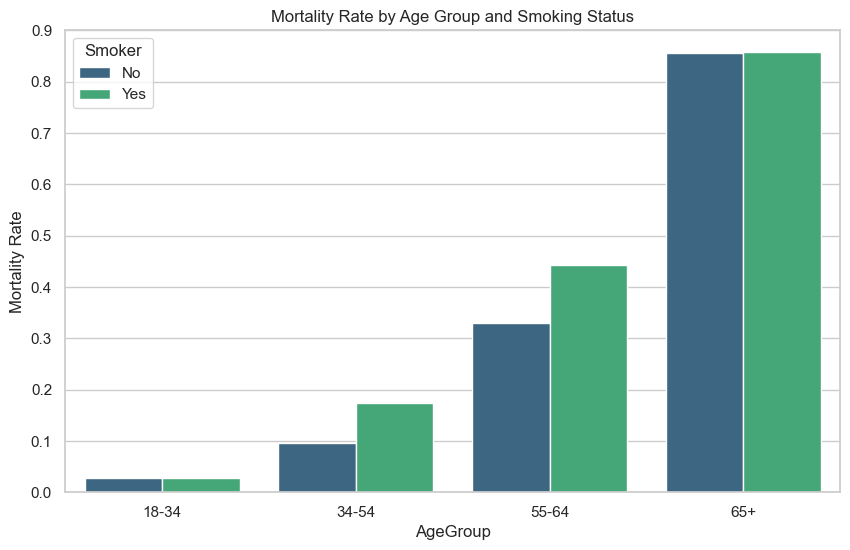

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], 
                        bins=[0, 34, 54, 64, 100], 
                        labels=['18-34', '34-54', '55-64', '65+'])

tab2 = df.groupby(['AgeGroup', 'Smoker', 'Status'], observed=False).size().unstack(fill_value=0)
tab2['Total'] = tab2['Alive'] + tab2['Dead']
tab2['Mortality_Rate'] = tab2['Dead'] / tab2['Total']

display(tab2[['Total', 'Mortality_Rate']])

tab2_reset = tab2.reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=tab2_reset, x='AgeGroup', y='Mortality_Rate', hue='Smoker', palette="viridis")
plt.title('Mortality Rate by Age Group and Smoking Status')
plt.ylabel('Mortality Rate')
plt.show()

### Explanation of the Paradox
When we control for age, the trend reverses: **in every age group (except the youngest where mortality is very low), smokers have a higher mortality rate than non-smokers.**

This is a classic example of **Simpson's Paradox**. The global rate was misleading because:
1. Mortality increases with age.
2. The non-smoker group has a much larger proportion of elderly women compared to the smoker group.

We can verify the age distribution difference below:

Average Age by Group:
Smoker
No     49.815847
Yes    44.269759
Name: Age, dtype: float64


C:\Users\Youssef Shawky\AppData\Local\Temp\ipykernel_30992\3104383900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Smoker', y='Age', data=df, palette="viridis")


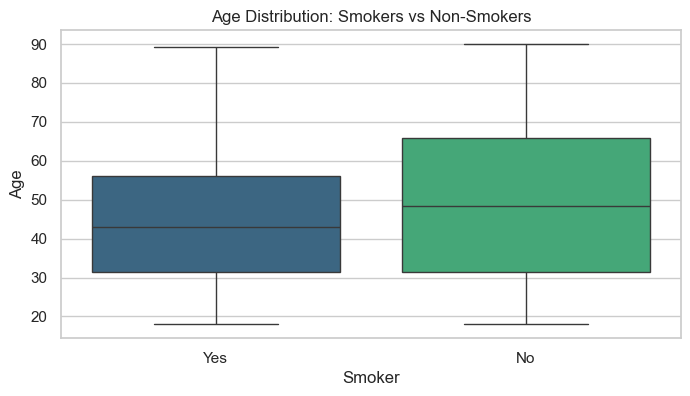

In [ ]:
print("Average Age by Group:")
print(df.groupby('Smoker')['Age'].mean())

plt.figure(figsize=(8, 4))
sns.boxplot(x='Smoker', y='Age', data=df, palette="viridis")
plt.title('Age Distribution: Smokers vs Non-Smokers')
plt.show()

## 4. Logistic Regression Analysis (Question 3)

**Objective:** To avoid bias from arbitrary age binning, we model the probability of death as a continuous function of age using Logistic Regression.

We model: $P(\text{Death}) \sim \text{Age} + \text{Smoker}$

<Figure size 1000x600 with 0 Axes>

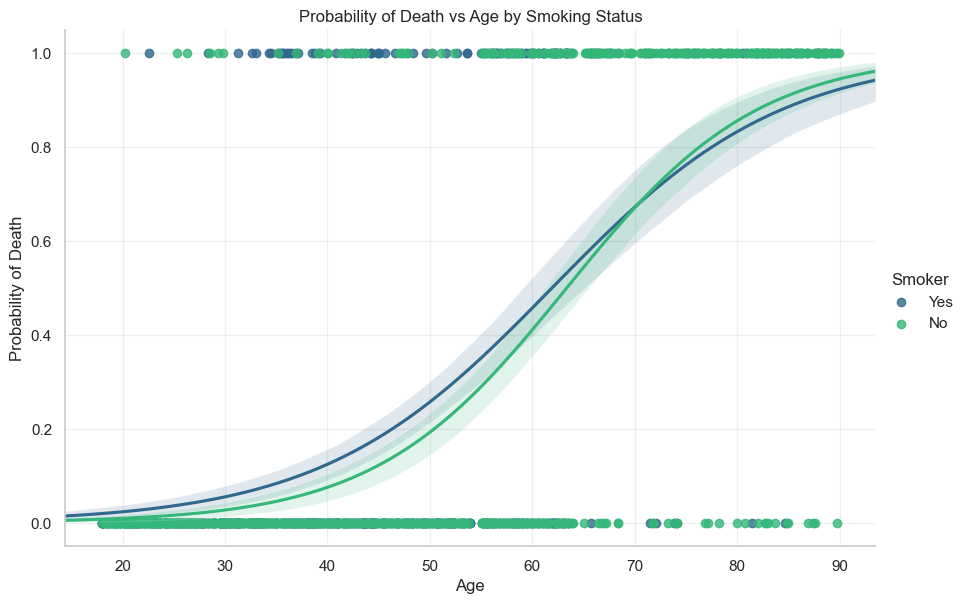

Optimization terminated successfully.
         Current function value: 0.381244
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Death_Val   No. Observations:                 1314
Model:                          Logit   Df Residuals:                     1311
Method:                           MLE   Df Model:                            2
Date:                Mon, 05 Jan 2026   Pseudo R-squ.:                  0.3579
Time:                        01:05:56   Log-Likelihood:                -500.95
converged:                       True   LL-Null:                       -780.16
Covariance Type:            nonrobust   LLR p-value:                5.534e-122
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -6.3519      0.360    -17.637      0.000      -7.058      -5.646
Smoker[T.Yes]     0.

In [ ]:
df['Death_Val'] = df['Status'].apply(lambda x: 1 if x == 'Dead' else 0)

plt.figure(figsize=(10, 6))
sns.lmplot(x='Age', y='Death_Val', hue='Smoker', data=df, 
           logistic=True, truncate=False, palette="viridis", height=6, aspect=1.5)
plt.title('Probability of Death vs Age by Smoking Status')
plt.ylabel('Probability of Death')
plt.grid(True, alpha=0.3)
plt.show()

model = smf.logit("Death_Val ~ Age + Smoker", data=df).fit()
print(model.summary())

## Conclusion

The logistic regression plot shows that for any given age, the probability of death is consistently higher for smokers (the orange curve) than for non-smokers (the blue curve). The confidence intervals (shaded areas) do not overlap significantly in the central age ranges, indicating a statistically significant difference.

**Final Conclusion:** By conducting a stratified analysis and logistic regression, we have resolved the Simpson's Paradox observed in the raw data. The analysis supports the conclusion that **smoking is associated with a higher mortality rate** when age is properly taken into account.